In [1]:
import numpy as np
import pandas as pd

import os

import datetime, warnings
warnings.filterwarnings("ignore")

import kagglehub

In [2]:
# Download latest version
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")

print("Path to dataset files:", path)

data_path = os.path.join( path, 'flight_data_2024.csv')

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\hrishitpatil\flight-data-2024\versions\2


In [3]:
#data_path = './flight_data_2024.csv'

In [4]:
def ver_df(path, columna_buscar):
    df = pd.read_csv(path, encoding='utf-8', sep=',')

    print(f"cantidad de muestras: {df.shape[0]}")
    print(f"cantidad de columnas: {df.shape[1]}")
    #print(f'Demo del data frame: \n{df.head(15)}')
    print(f'info del data frame: \n{df.info()}')
    print(f'descripción del data frame: \n{df.describe()}')
    print(f'columnas con valores nulos: \n{df.isna().sum()}')
    print(f'cantidad de valores del data frame: \n{df[columna_buscar].value_counts()}')
    print(f"cantidad de muestras validas: \n {df.shape[0]-df[columna_buscar].isna().sum()}")
    return df

In [5]:
df = ver_df(data_path, 'arr_delay')

cantidad de muestras: 7079081
cantidad de columnas: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              object 
 5   op_unique_carrier    object 
 6   op_carrier_fl_num    float64
 7   origin               object 
 8   origin_city_name     object 
 9   origin_state_nm      object 
 10  dest                 object 
 11  dest_city_name       object 
 12  dest_state_nm        object 
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay  

In [6]:
df.sample(10)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
6383268,2024,11,25,1,2024-11-25,DL,807.0,JFK,"New York, NY",New York,...,0,351.0,358.0,332.0,2248.0,0,0,0,0,0
2830263,2024,5,31,5,2024-05-31,AA,1303.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,161.0,175.0,130.0,936.0,121,0,14,0,0
3722740,2024,7,14,7,2024-07-14,9E,5374.0,CSG,"Columbus, GA",Georgia,...,0,59.0,62.0,28.0,83.0,0,0,3,0,42
2876710,2024,6,2,7,2024-06-02,G4,2842.0,SFB,"Sanford, FL",Florida,...,0,172.0,161.0,144.0,1144.0,0,0,0,0,0
6657794,2024,12,9,1,2024-12-09,WN,1507.0,DAL,"Dallas, TX",Texas,...,0,160.0,168.0,146.0,879.0,0,0,0,0,0
6847385,2024,12,19,4,2024-12-19,WN,3658.0,SAN,"San Diego, CA",California,...,0,80.0,NaN,NaN,258.0,0,0,0,0,0
292241,2024,1,17,3,2024-01-17,NK,369.0,DTW,"Detroit, MI",Michigan,...,0,178.0,168.0,153.0,1084.0,0,0,0,0,0
5340081,2024,10,3,4,2024-10-03,DL,2114.0,MSP,"Minneapolis, MN",Minnesota,...,0,242.0,238.0,201.0,1535.0,0,0,0,0,0
1364265,2024,3,16,6,2024-03-16,WN,2051.0,SFO,"San Francisco, CA",California,...,0,90.0,83.0,73.0,414.0,0,0,0,0,0
2947399,2024,6,5,3,2024-06-05,WN,4940.0,BWI,"Baltimore, MD",Maryland,...,0,235.0,219.0,200.0,1491.0,0,0,0,0,0


#***Limpieza del data frame***

#*Limpiado NA*

In [7]:
columnas_con_nulos = ['op_carrier_fl_num', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'arr_time', 'arr_delay', 'actual_elapsed_time','actual_elapsed_time', 'air_time']

df.dropna(subset=columnas_con_nulos, inplace=True)

total_filas = len(df)

print(total_filas)

6965266


In [8]:
df.sample(5)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3060428,2024,6,11,2,2024-06-11,G4,2844.0,BMI,"Bloomington/Normal, IL",Illinois,...,0,139.0,133.0,118.0,917.0,0,0,0,0,0
1665400,2024,4,1,1,2024-04-01,DL,735.0,BOS,"Boston, MA",Massachusetts,...,0,212.0,223.0,202.0,1124.0,0,0,0,0,0
4291606,2024,8,10,6,2024-08-10,OH,5323.0,BTV,"Burlington, VT",Vermont,...,0,144.0,144.0,116.0,761.0,0,0,0,0,31
4636401,2024,8,27,2,2024-08-27,WN,3491.0,BOI,"Boise, ID",Idaho,...,0,110.0,102.0,81.0,649.0,0,0,0,0,0
1423794,2024,3,19,2,2024-03-19,WN,3366.0,MSY,"New Orleans, LA",Louisiana,...,0,95.0,92.0,71.0,444.0,0,0,0,0,0


In [9]:
#df.drop_duplicates(inplace=True)

In [10]:
columnas = df.columns
print(columnas)

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date',
       'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name',
       'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm',
       'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off',
       'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay',
       'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time',
       'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay',
       'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'],
      dtype='object')


In [11]:
df.head(15)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0
5,2024,1,1,1,2024-01-01,9E,4822.0,JAX,"Jacksonville, FL",Florida,...,0,137.0,120.0,102.0,833.0,0,0,0,0,0
6,2024,1,1,1,2024-01-01,9E,4822.0,LGA,"New York, NY",New York,...,0,169.0,164.0,125.0,833.0,0,0,0,0,0
7,2024,1,1,1,2024-01-01,9E,4823.0,CHS,"Charleston, SC",South Carolina,...,0,118.0,99.0,86.0,641.0,0,0,0,0,0
8,2024,1,1,1,2024-01-01,9E,4823.0,LGA,"New York, NY",New York,...,0,149.0,123.0,101.0,641.0,0,0,0,0,0
9,2024,1,1,1,2024-01-01,9E,4828.0,ITH,"Ithaca/Cortland, NY",New York,...,0,79.0,67.0,43.0,189.0,0,0,0,0,0


#*Convertir de millas a km el campo dist*

In [12]:
df['distancia_km'] = df['distance'] * 1.60934

In [13]:
df.head(15)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,distancia_km
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,136.0,122.0,84.0,509.0,0,0,0,0,0,819.15406
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,130.0,114.0,88.0,622.0,0,0,0,0,0,1001.00948
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,106.0,90.0,61.0,288.0,0,0,0,0,0,463.48992
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,111.0,76.0,51.0,288.0,0,0,0,0,0,463.48992
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,79.0,70.0,45.0,237.0,0,0,0,0,0,381.41358
5,2024,1,1,1,2024-01-01,9E,4822.0,JAX,"Jacksonville, FL",Florida,...,137.0,120.0,102.0,833.0,0,0,0,0,0,1340.58022
6,2024,1,1,1,2024-01-01,9E,4822.0,LGA,"New York, NY",New York,...,169.0,164.0,125.0,833.0,0,0,0,0,0,1340.58022
7,2024,1,1,1,2024-01-01,9E,4823.0,CHS,"Charleston, SC",South Carolina,...,118.0,99.0,86.0,641.0,0,0,0,0,0,1031.58694
8,2024,1,1,1,2024-01-01,9E,4823.0,LGA,"New York, NY",New York,...,149.0,123.0,101.0,641.0,0,0,0,0,0,1031.58694
9,2024,1,1,1,2024-01-01,9E,4828.0,ITH,"Ithaca/Cortland, NY",New York,...,79.0,67.0,43.0,189.0,0,0,0,0,0,304.16526


In [14]:
aerolineas = {'9E': 'Endeavor Air', 'AA': 'American Airlines', 'AS': 'Alaska Airlines', 'B6': 'JetBlue Airways', 'DL': 'Delta Air Lines', 'F9': 'Frontier Airlines', 'G4': 'Allegiant Air', 'HA': 'Hawaiian Airlines', 'MQ': 'Envoy Air', 'NK': 'Spirit Airlines', 'OH': 'PSA Airlines', 'OO': 'SkyWest Airlines', 'UA': 'United Airlines', 'WN': 'Southwest Airlines', 'YX': 'Republic Airways'}

In [15]:
df['retraso'] = np.where(df['arr_delay']>0, 1, 0)

In [16]:
df.sample(15)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,distancia_km,retraso
4692021,2024,8,30,5,2024-08-30,UA,1696.0,EWR,"Newark, NJ",New Jersey,...,147.0,122.0,937.0,0,0,0,0,0,1507.95158,0
3553690,2024,7,5,5,2024-07-05,WN,1394.0,OMA,"Omaha, NE",Nebraska,...,63.0,49.0,342.0,0,0,0,0,0,550.39428,0
5967463,2024,11,3,7,2024-11-03,WN,3401.0,PNS,"Pensacola, FL",Florida,...,70.0,60.0,391.0,0,0,0,0,0,629.25194,0
465137,2024,1,27,6,2024-01-27,B6,2473.0,JFK,"New York, NY",New York,...,119.0,98.0,636.0,0,0,0,0,0,1023.54024,0
659089,2024,2,7,3,2024-02-07,DL,843.0,ATL,"Atlanta, GA",Georgia,...,292.0,275.0,1892.0,0,0,0,0,0,3044.87128,0
5250430,2024,9,28,6,2024-09-28,UA,1729.0,ROC,"Rochester, NY",New York,...,140.0,80.0,528.0,0,0,0,0,0,849.73152,1
2706019,2024,5,24,5,2024-05-24,UA,1158.0,LAX,"Los Angeles, CA",California,...,337.0,312.0,2556.0,0,0,0,0,0,4113.47304,0
3668120,2024,7,11,4,2024-07-11,DL,780.0,AUS,"Austin, TX",Texas,...,260.0,231.0,1770.0,0,0,0,0,0,2848.53180,0
6145081,2024,11,13,3,2024-11-13,DL,662.0,PDX,"Portland, OR",Oregon,...,261.0,242.0,2172.0,0,0,0,0,0,3495.48648,0
6312426,2024,11,21,4,2024-11-21,WN,512.0,SJC,"San Jose, CA",California,...,73.0,58.0,342.0,0,0,0,0,0,550.39428,0


In [17]:
#columnas_basura = ['cancellation_code', 'distance', 'fl_date', 'cancelled', 'arr_delay']
"""nuevos_nombres_columnas = {'op_unique_carrier':'codigo_unico_aerolinea',
                              'dest':'codigo_destino',
                              'dep_time':'hora_salida',
                              'year':'año',
                              'month':'mes',
                              'day_of_month':'dia_mes',
                              'origin':'codigo_origen',
                              }
"""
#df.drop(columns=columnas_basura, inplace=True)

"nuevos_nombres_columnas = {'op_unique_carrier':'codigo_unico_aerolinea',\n                              'dest':'codigo_destino',\n                              'dep_time':'hora_salida',\n                              'year':'año',\n                              'month':'mes',\n                              'day_of_month':'dia_mes',\n                              'origin':'codigo_origen',\n                              }\n"

##**Exploración**

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
data = df['retraso'].groupby(df['op_unique_carrier']).value_counts()
data

op_unique_carrier  retraso
9E                 0          144070
                   1           51002
AA                 0          561389
                   1          404727
AS                 0          140780
                   1           99543
B6                 0          144132
                   1           91551
DL                 0          682270
                   1          315576
F9                 0          114601
                   1           88880
G4                 0           74877
                   1           40005
HA                 0           44286
                   1           33347
MQ                 0          173870
                   1          101447
NK                 0          159000
                   1           96633
OH                 0          141158
                   1           82515
OO                 0          485665
                   1          248221
UA                 0          490577
                   1          255241
WN         

# **Colunmas a eliminar**

In [20]:
columnas_basura = ['cancellation_code', 'distance', 'fl_date', 'cancelled', 'arr_delay']
"""nuevos_nombres_columnas = {'op_unique_carrier':'codigo_unico_aerolinea',
                              'dest':'codigo_destino',
                              'dep_time':'hora_salida',
                              'year':'año',
                              'month':'mes',
                              'day_of_month':'dia_mes',
                              'origin':'codigo_origen',
                              }
"""
df.drop(columns=columnas_basura, inplace=True)

Text(0, 0.5, 'Cantidad de vuelos')

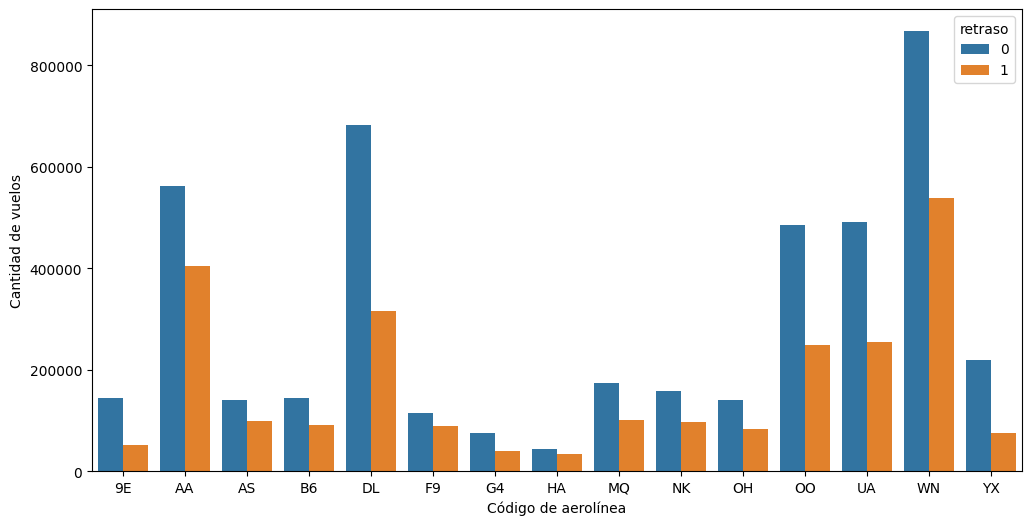

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(x=data.index.get_level_values(0), y=data.values, hue=data.index.get_level_values(1))
plt.xlabel('Código de aerolínea')
plt.ylabel('Cantidad de vuelos')

In [22]:
data = df['retraso'].groupby(df['origin']).value_counts()
data

origin  retraso
ABE     0           3178
        1           1069
ABI     0           1177
        1            564
ABQ     0          16148
                   ...  
XWA     1            611
YAK     0            512
        1            187
YUM     0           1237
        1            474
Name: count, Length: 696, dtype: int64

In [23]:
top10_origen = data.nlargest(10)
top10_origen

origin  retraso
ATL     0          214317
DEN     0          184443
DFW     0          175257
ORD     0          167553
DFW     1          131615
LAX     0          125211
ATL     1          123345
PHX     0          122364
DEN     1          119880
CLT     0          119484
Name: count, dtype: int64

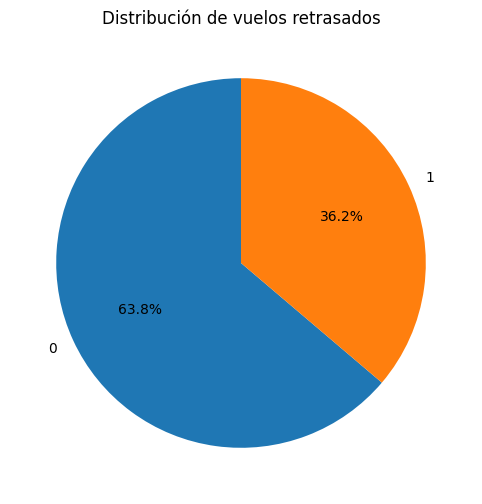

In [24]:
data = df['retraso'].value_counts()
plt.figure(figsize=(10, 6))
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribución de vuelos retrasados')
plt.show()

Text(0, 0.5, 'Cantidad de vuelos')

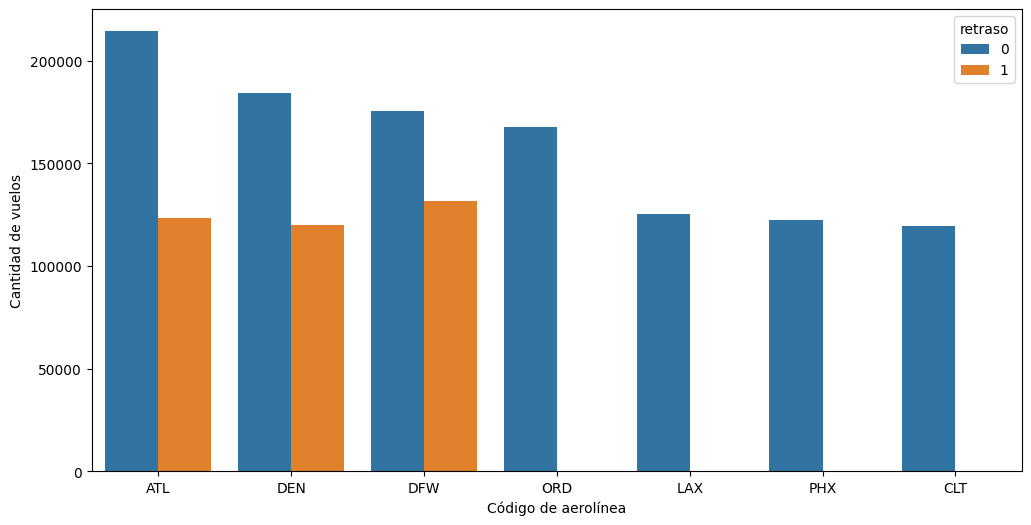

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top10_origen.index.get_level_values(0), y=top10_origen.values, hue=top10_origen.index.get_level_values(1))
plt.xlabel('Código de aerolínea')
plt.ylabel('Cantidad de vuelos')

In [26]:
y = df['retraso']
X = df.drop(['retraso'], axis=1)

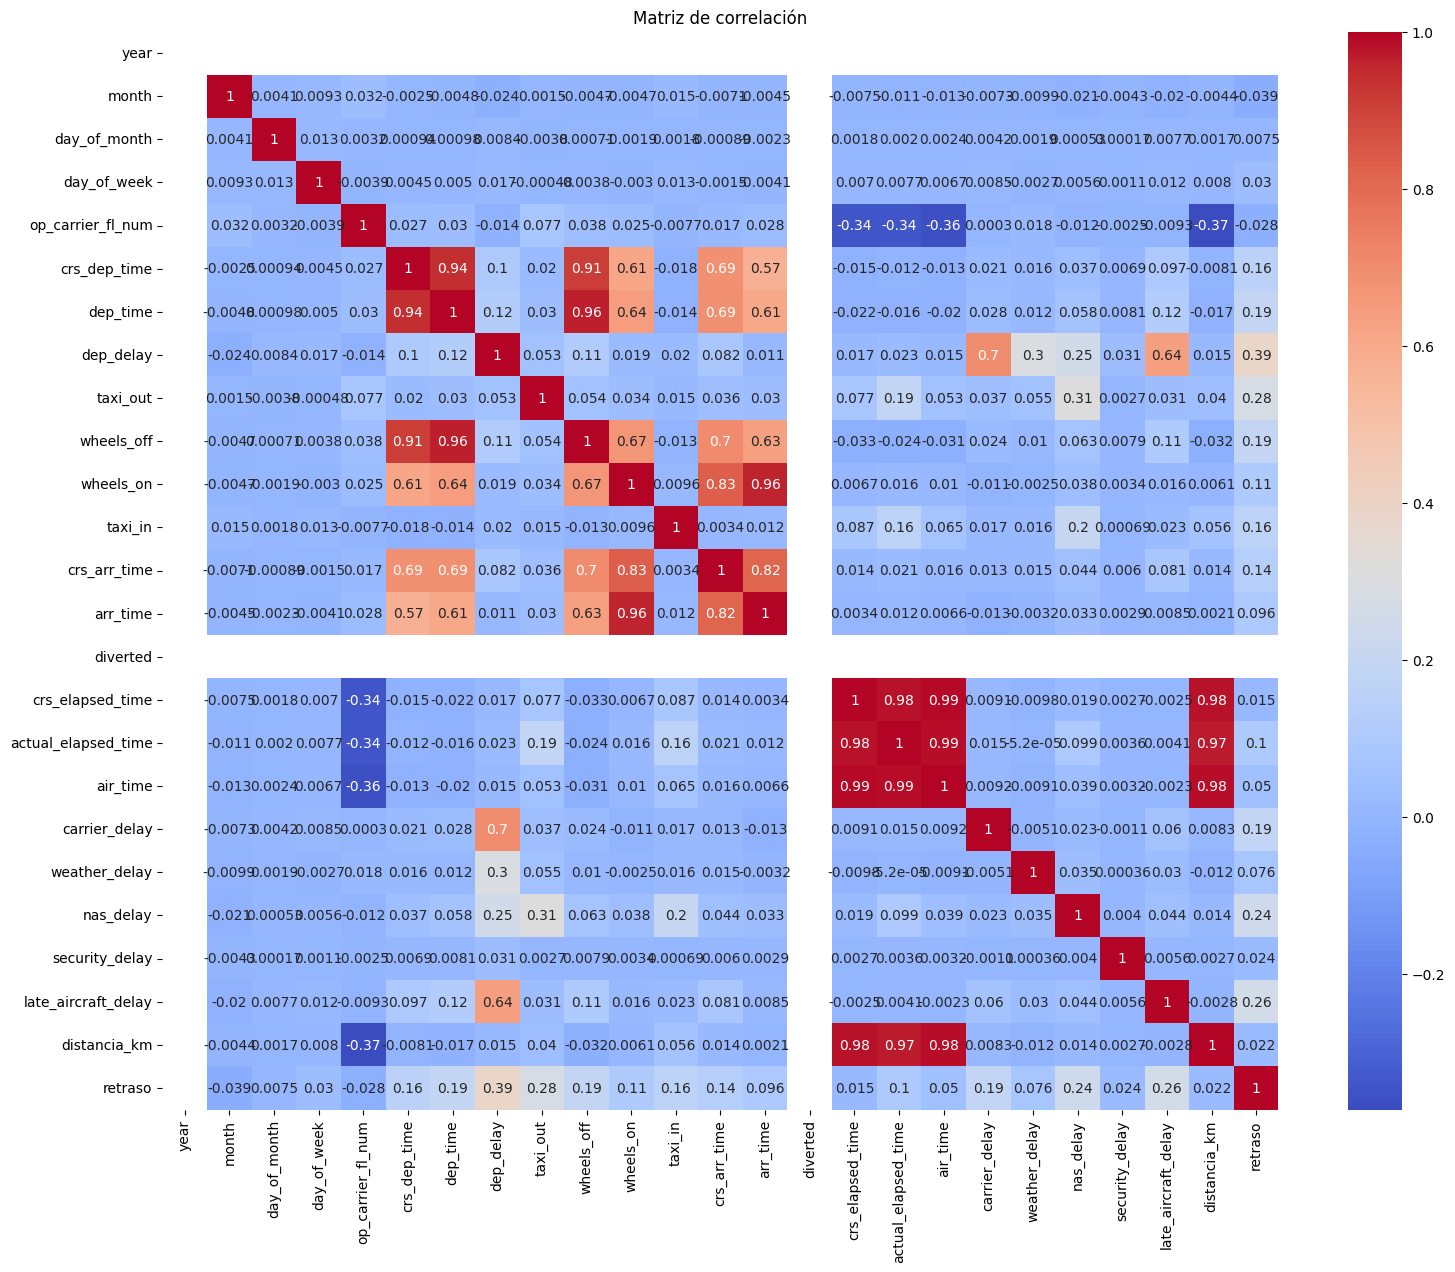

In [27]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

#**Preproceso**

In [28]:
from sklearn.compose import make_column_selector as selector

In [29]:
cat_selector = selector(dtype_include=['object', 'category'])
variables_categoricas = cat_selector(df)

In [30]:
print(variables_categoricas)

['op_unique_carrier', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm']


In [31]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [32]:
one_hot = make_column_transformer(
    (OneHotEncoder(
        drop="if_binary", 
        handle_unknown="ignore", 
        sparse_output=True  
    ), variables_categoricas),
    remainder="passthrough",
    sparse_threshold=1.0     
)

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score,confusion_matrix, ConfusionMatrixDisplay, r2_score

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=200)

In [35]:
model_arbol = Pipeline(steps=[
    ("preprocessor", one_hot),
    ("classifier", RandomForestClassifier(random_state=200, class_weight="balanced", max_depth=5))
])

In [36]:
model_arbol.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [40]:
y_pred = model_arbol.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8671458536424288
              precision    recall  f1-score   support

           0       0.86      0.95      0.90    889169
           1       0.90      0.72      0.80    503885

    accuracy                           0.87   1393054
   macro avg       0.88      0.83      0.85   1393054
weighted avg       0.87      0.87      0.86   1393054



[[846859  42310]
 [142763 361122]]


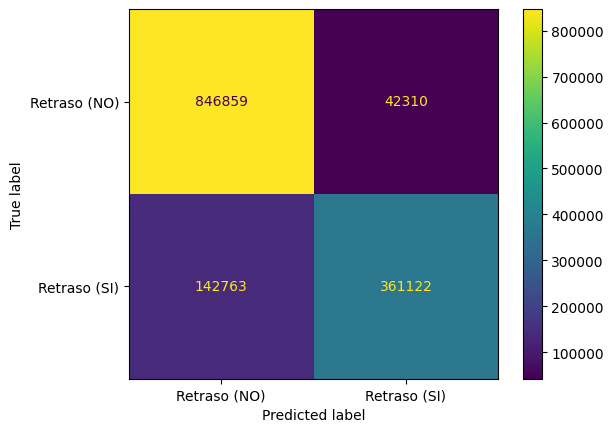

In [38]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)
visualizacion = ConfusionMatrixDisplay(matrix, display_labels=['Retraso (NO)', 'Retraso (SI)'])
visualizacion.plot()

In [39]:
import joblib

# Cargar el modelo desde el archivo
joblib.dump(model_arbol, 'modelo_random_pre_forest_v1.joblib', compress=3)

['modelo_random_pre_forest_v1.joblib']